<a href="https://colab.research.google.com/github/mat381/2026_Intro_Python/blob/main/1.1-environment-and-data-types.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

> Notebook-friendly copy of `part-I/1.1-environment-and-data-types.ipynb`, generated by `tools/make_live.py`. Edit the book notebook, not this file.

In [ ]:
# --- environment setup (generated, not part of the lesson) ---
# Colab and Kaggle start in an empty working directory.
# This is a no-op in an environment that is already set up.
from pathlib import Path

Path("_files").mkdir(exist_ok=True)   # the folder this notebook writes into

# 1.1) Variables, Data Types, Operators and File I/O

This notebook builds the smallest complete toolkit for handling environmental data in Python: variables, the core scalar types, arithmetic, casting, string formatting, and reading and writing text files.

We work throughout with one running example, a week of daily maximum air temperatures from the Jungfraujoch research station in the Swiss Alps, and finish by showing how a single type confusion can make generated code return the wrong answer without raising an error.

**ℹ️ Before you start**

This subchapter assumes you can run a notebook, nothing more. If you have not set up Python on your own machine yet, either run this page in Google Colab using the badge above, or follow the [setup instructions](../appendix/appendix.md) first. Git and uv are introduced there and are not needed to follow along here.

<img src="https://raw.githubusercontent.com/gse-unil/2026_MLEES_book/main/part-I/_static/haim_charbit-snake-7386684.jpg" alt="Photograph of a green python" width="800">

<em>Image by <a href="https://pixabay.com/users/haim_charbit-18266955/?utm_source=link-attribution&amp;utm_medium=referral&amp;utm_campaign=image&amp;utm_content=7386684">haim charbit</a> from <a href="https://pixabay.com//?utm_source=link-attribution&amp;utm_medium=referral&amp;utm_campaign=image&amp;utm_content=7386684">Pixabay</a></em>

**🎯 Learning objectives**

- Create variables whose names encode the physical quantity and its unit.
- Distinguish Python's core scalar types and inspect them with type().
- Apply arithmetic, comparison, and casting to environmental measurements.
- Format numbers and units cleanly with f-strings.
- Read and write small text files with pathlib, and cast text back to numbers.
- Recognise why values read from files are strings, and the silent bugs that follow.

## 1.1.1 Variables and the Core Scalar Types

A variable binds a name to a value, and Python infers the value's *type*, which determines what operations are allowed. Five scalar types cover almost everything a single measurement needs: `int` (whole counts) , `float` (real-valued measurements), `str` (text), `bool` (true/false flags), and `None` (a deliberate "no value", useful for missing or not-yet-assigned information).

Our running example is the Jungfraujoch research station in the Swiss Alps (3571 m), one of the highest year-round weather stations in Europe. We have one week of daily maximum air temperatures from it. The number of readings is a whole count; each temperature is a decimal-point number.

In [ ]:
n_readings = 7                 # Integer (int): number of measurements, ne pas oublier de mettre l'unité dans le nom si possible
temp_celsius = -8.4            # Floating-point (float): degrees Celsius, day 1 of the week, ne pas oublier de mettre l'unité dans le nom si possible

print(n_readings, type(n_readings))      # print() displays a value, type() its type
print(temp_celsius, type(temp_celsius))

7 <class 'int'>
-8.4 <class 'float'>


The station also has a name, each reading can carry a flag that is either true or false, and a quality field may have no value assigned to it yet.

In [ ]:
station_name = "Jungfraujoch"  # String (str): name of the station
is_subzero = True              # Boolean (bool) (True and False): True if the temperature is below zero
quality_flag = None            # NoneType (None)(missing data): quality information not yet assigned

print(station_name, type(station_name))
print(is_subzero, type(is_subzero))
print(quality_flag, type(quality_flag))

Jungfraujoch <class 'str'>
True <class 'bool'>
None <class 'NoneType'>


| Data Type | Python Identifier | Operational Scope |
| --- | --- | --- |
| **Integer** | `int` | Whole numerical counts |
| **Floating-Point** | `float` | Real-valued measurements |
| **String** | `str` | Textual data |
| **Boolean** | `bool` | True/False logical flags |
| **NoneType** | `None` | Deliberate absence of value |

**🧠 Computational-thinking fundamental: a name is a contract**

A variable name should state the physical quantity and, where it has one, the unit. If `t1` and `t2` hold a Celsius value and a Kelvin value, swapping them by accident compiles and runs — the error only shows up later, as a temperature that is off by 273 degrees somewhere downstream of a calculation. Encoding the unit in the name (`temp_celsius`, `temp_kelvin`) turns that mistake into something visible while reading the code, before it ever runs.

**⚠️ Rules for naming a variable:**

- The first character of an identifier must be a letter (`a-z`, `A-Z`) or an underscore (`_`). It cannot be a digit (`0-9`).
- Subsequent characters are strictly confined to alphanumeric characters (`a-z`, `A-Z`, `0-9`) and underscores (`_`).
- Whitespace, hyphens, and punctuation symbols (`.`, `-`, `@`, `$`, `%`, `!`) are forbidden.
- `surface-temp` is parsed as subtraction (`surface` minus `temp`) and will fail if the names are undefined. `surface_temp` is the correct form.
- Python is a case-sensitive language. Therefore, `T_flux` and `t_flux` are distinct variables.
- Python's real keywords (`if`, `for`, `class`, `return`, ...) genuinely cannot be used as variable names — that is a `SyntaxError`. Built-in names like `print`, `id`, `open`, `min`, and `max` are different: reusing them as a variable name is legal but shadows the built-in for the rest of the scope, which is a common source of confusing bugs.

## 1.1.2 Arithmetic, Comparison, and Casting

**Arithmetic** (`+ - * / // % **`) and **comparison** (`< <= > >= == !=`) operators behave as in mathematics, with two things to watch:
1. `/` always returns a `float` even if the operands divide evenly, even if the answer is a int number;
2. Operators are *type-dependent*: `+` adds numbers but concatenates strings.

In [ ]:
# Arithmetic: unit conversions, with units encoded in the names
temp_kelvin = temp_celsius + 273.15
temp_fahrenheit = 9 / 5 * temp_celsius + 32
print("Temperature in Kelvin:", temp_kelvin, "K")
print("Temperature in Fahrenheit:", temp_fahrenheit, "F")

Temperature in Kelvin: 264.75 K
Temperature in Fahrenheit: 16.88 F


Two of the seven days in our week fell strictly below -9.0 °C. `/` gives the fraction of the week that was that cold, and always returns a `float`:

In [ ]:
# Division: / is always float, even when the numbers divide evenly
n_below_minus9 = 2
fraction_below = n_below_minus9 / n_readings
print("Fraction of days below -9 C:", fraction_below)

Fraction of days below -9 C: 0.2857142857142857


`//` and `%` split a count into whole groups and a remainder. Over a longer record — the station's full January, 31 days — they answer "how many complete weeks, and how many days left over?":
%=reste de la division entière

In [ ]:
n_days_january = 31
print("Complete weeks:", n_days_january // 7)   # floor division: 4
print("Days left over:", n_days_january % 7)    # remainder (modulus): 3

Complete weeks: 4
Days left over: 3


In [ ]:
# Comparison operators return bool
print(temp_kelvin > 270.0)

Four operator families appear throughout this book, including the comparison operators you have just met.

| Family | Operators | What they do |
| --- | --- | --- |
| Comparison | `<` `<=` `>` `>=` `==` `!=` | Compare two values, return a `bool` |
| Assignment | `=` `+=` `-=` `*=` `/=` | Assign, or update a variable in place |
| Logical | `and` `or` `not` | Combine or negate `bool` values |
| Identity | `is` `is not` | Test whether two names refer to the same object |

`count += 1` is shorthand for `count = count + 1`. Use `is` only to compare with `None`;
for values, use `==`.

In [ ]:
# Assignment operators update a variable in place ->raccourci d'opération en gros
count = 0
count += 3          # same as count = count + 3
count -= 1
count *= 2
print(count)        # 4

4


In [ ]:
# Logical operators: `and` needs both, `or` needs at least one
print(temp_celsius)
is_freezing = temp_celsius < 0.0
is_valid = temp_celsius > -273.15
print(is_freezing and is_valid)   # True: both conditions hold
print(is_freezing or False)       # True: at least one holds

-8.4
True
True


In [ ]:
# `not` negates a bool (switch a boolean true to false ou false to true, mais en gros c'est une négation : n'est pas); `is` tests identity, which is how you check for None
print(not is_freezing)            # False
print(quality_flag is None)       # True
print(temp_celsius is not None)   # True

False
True
True


Use the Exercises section to explore all the different comparison operators.

**Casting** converts between types with `int()`, `float()`, and `str()`. The station also logs air pressure, and at 3571 m it is far below sea level pressure — around 651 hPa, or 65120 Pa. Here it arrives as text:

In [ ]:
# Values read from text arrive as str and must be cast before arithmetic
raw = "65120.0"                   # station air pressure, Pa, as text
print(raw, type(raw))

65120.0 <class 'str'>


In [ ]:
# Execution would halt here due to TypeError:
print(float(raw) + 1.0)

TypeError: can only concatenate str (not "float") to str

In [ ]:
pressure_pa = float(raw)
print(pressure_pa, type(pressure_pa))
print(pressure_pa + 100.0)        # now arithmetic works

count_str = str(n_readings)       # casting the other way, to build text / n_reading est un int number d'avant
print(count_str + " readings")    # str + str concatenates

65120.0 <class 'float'>
65220.0
7 readings


In [ ]:
print(int(3.99))                  # truncates toward zero -> 3, not 4, n'arrondi pas, round (arrondi) et floor (réduit)

3


**⚠️ Common mistake**: `int()` truncates, it does not round**

`int(3.99)` is `3`, not `4`: casting a float to int discards the fractional part toward zero.

Negative numbers truncate toward zero too, not toward negative infinity: `int(-3.99)` is `-3`, not `-4`, and `int(-2.5)` is `-2`, not `-3`.

## 1.1.3 Rounding Numbers

Use `round()` for nearest-integer behaviour. A second argument says how many decimal places to keep.

In [ ]:
print(round(1.666667, 2))       # round to 2 decimal places

1.67


**⚠️ Note: `round()` uses round-half-to-even**

`round(2.5)` is `2`, not `3`, which is surprising if you expect schoolbook rounding. Halfway cases go to the nearest even number, so `round(3.5)` is `4`.

## 1.1.4 Formatting Numbers with f-strings

f-strings (`f"..."`) interpolate variables and apply a **format specifier** after a colon: `:.2f` fixes **two decimals**, `:.3e` uses **scientific notation**, `:.1%` formats a **fraction as a percentage**. This keeps reported precision honest and units explicit.

In [ ]:
# f-strings interpolate values and apply format specifiers after ':'
# f"{}"" permet d'exprimer la valeur d'une variable (dans {}) dans une zone de text "" ->très interessant
#.2f = spécifier nombre décimal du float à afficher, .3e met en notion scientifique
print(pressure_pa)
print(f"{station_name}: {temp_celsius:.1f} °C ({temp_kelvin:.2f} K)")
print(f"pressure = {pressure_pa:.3e} Pa")
print(f"days below -9 °C = {fraction_below:.1%}")

65120.0
Jungfraujoch: -8.4 °C (264.75 K)
pressure = 6.512e+04 Pa
days below -9 °C = 28.6%


## 1.1.5 Working with Text

Measurements often arrive embedded in text — station records, log lines, CSV fields.

A string is a sequence of characters, so you can pick out single characters by **index** and ranges of them by **slice**. Indexing starts at 0; negative indices count from the end.

In [ ]:
# indexing: single characters, -1, -2,-3,...-> donne les lettres en partant depuis la fin
print(station_name[0], station_name[-1])     # J h

J h


A slice `[start:stop]` includes `start` and excludes `stop`. Either end can be left out, and it defaults to the beginning or the end of the string.

In [ ]:
# slicing: [start:stop] includes start, excludes stop
print(station_name[0:5])    # Jungf
print(station_name[:5])     # Jungf  — start defaults to 0
print(station_name[5:])     # raujoch — stop defaults to the end
print(station_name[-4:])    # joch   — the last four characters

Station records are often *fixed width*: every field always occupies the same positions, so slicing alone can take them apart. Here the first three characters are the station code and the rest is the date.

In [ ]:
record = "JFJ2022-01-03"
print(record[:3])           # JFJ  — the station code
print(record[3:])           # 2022-01-03 — the date

The same slicing syntax will return on lists in the next subchapter and on arrays in 1.3.

Not every record is that tidy. String methods clean them up: `.strip()` removes surrounding whitespace, `.split(sep)` breaks a string into parts, and `.lower()`/`.upper()`/`.title()` normalise case. The parts are still text and must be cast before arithmetic.

In [ ]:
# the same station, logged messily: extra spaces, mixed case, comma-separated
record = "        JUNGFRAUJOCH , -9.2 , degC  "
fields = record.split(",")  #.split casse le texte en liste au niveau du ",", si la séparation etait des espaces dans le fichier text on peut séparer par " ".
print(fields)
record2="Rocher de Naye"
liste= record2.split(" ")
print(liste)

['        JUNGFRAUJOCH ', ' -9.2 ', ' degC  ']
['Rocher', 'de', 'Naye']


In [ ]:
name = fields[0].strip().title() #.strip enlève les espaces dans l'ensemble de carractères entre "," et ","/
print(name)                       #.title met la chaine de carractère comme le premier mot d'un titre (majuscule à la première lettre, puis minuscule)
                                   #.upper met en majuscule du carractère string, .lower met en minuscule du carractère string

Jungfraujoch


In [ ]:
value_celsius = float(fields[1].strip())  #enlève espace et le transforme en chiffre float
print(value_celsius)

-9.2


In [ ]:
unit = fields[2].strip().lower()  #enlève espaces et met tout en minuscule
print(unit)

degc


## 1.1.6 Importing Libraries

Python keeps extra tools in *libraries* (also called modules), and you bring them into your environment with `import`. The standard library ships with many tools; `math` is a good example, and the exercises for this subchapter use it.

In [ ]:
import math

print(math.sqrt(16))    # 4.0
print(math.pi)          # 3.141592653589793

4.0
3.141592653589793


## 1.1.7 Files and Paths with pathlib

Standard `.txt` and `.csv` files are universally readable plain text. `pathlib.Path` builds filesystem paths in an os-independent way (no hand-written `/` or `\`). We open paths with `.open()`, specifying a mode:

| Mode | Meaning |
| --- | --- |
| `"r"` | Read an existing file (the default); fails if it does not exist |
| `"w"` | Write, creating the file or **overwriting** everything in it |
| `"a"` | Append, adding to the end and keeping the existing contents |

An open file must be closed again, or the last writes may never reach disk. Doing that by
hand is easy to forget, so the standard form is a `with` block, which closes the file for you
as soon as the block ends — even if an error occurs inside it.

In [ ]:
from pathlib import Path                     #Path permet de travailler avec les chemins de fichiers et de dossiers de manière plus pratique

data_path = Path("_files/station_daily.csv") # 1. Indique où se trouve le fichier
                                             #.parent permet d'obtenir le dossier qui contient le fichier
data_path.parent.mkdir(exist_ok=True)        #.mkdir (make directory) create the folder if needed -> Crée le dossier "_files" s'il n'existe pas
                                             #Sans "exist_ok=True", Python pourrait générer une erreur si _files existe déjà.

print(f"Does the file exist? {data_path.exists()}") # 3. Vérifier si le fichier existe

Does the file exist? False


Open the path in mode `"w"` to create the file and write the header row plus the first day of the week. The `with` block closes it again as soon as the indented lines are done.

With=fonction qui s'occuppe d'ouvrir et fermer un dossier

In [ ]:
# "w" creates the file (or overwrites it); the with block closes it automatically ->très pratique permet qu'il s'enregistre dans le drive
with data_path.open("w", encoding="utf-8") as fhandler:   #encoding="utf-8" = utilise UTF-8 pour traduire les données du fichier en texte lisible et inversement
    fhandler.write("station,day,max_temp_celsius\n")      #.open ouvre le fichier/"w" type d'action, ici write ou overwrite/"as ..." donne un nom à ce fichier ouvert.
    fhandler.write("JFJ,2022-01-01,-8.4\n")

print(f"Does the file exist now? {data_path.exists()}")

Does the file exist now? True
<_io.TextIOWrapper name='_files/station_daily.csv' mode='w' encoding='utf-8'>


Mode `"a"` reopens the same file and adds to the end instead of overwriting it. That gets the remaining six days of the week in.

In [ ]:
with data_path.open("a", encoding="utf-8") as fhandler:
    fhandler.write("JFJ,2022-01-02,-8.9\n")
    fhandler.write("JFJ,2022-01-03,-9.2\n")
    fhandler.write("JFJ,2022-01-04,-9.0\n")
    fhandler.write("JFJ,2022-01-05,-9.5\n")
    fhandler.write("JFJ,2022-01-06,-7.8\n")
    fhandler.write("JFJ,2022-01-07,-6.1\n")

In [ ]:
# "r" reads it back; .read() returns the whole file as one string ->lire file, mais donne ça sous forme de grand texte
with data_path.open("r", encoding="utf-8") as fhandler:
    raw_text = fhandler.read()

print(raw_text)

station,day,max_temp_celsius
JFJ,2022-01-01,-8.4
JFJ,2022-01-02,-8.9
JFJ,2022-01-03,-9.2
JFJ,2022-01-04,-9.0
JFJ,2022-01-05,-9.5
JFJ,2022-01-06,-7.8
JFJ,2022-01-07,-6.1



<details>
<summary><b>🔍 Going deeper: the manual form, and the built-in <code>open()</code></b></summary>

You will also see code that manages files by hand, calling `.open()` and then `.close()` yourself
instead of using a `with` block:

```python
fhandler = data_path.open("a", encoding="utf-8")
fhandler.write("JFJ,2022-01-08,-5.4\n")
fhandler.close()
```

It behaves the same as long as the `close()` call is never skipped — but an exception raised
between `open()` and `close()` leaves the file unclosed, and it is easy to forget the call
entirely. The `with` block avoids both risks, which is why it is the pattern used throughout the
rest of this book. Recognise the manual form in code you did not write; do not adopt it.

You will also meet the built-in `open()` used directly on a path that is already a plain string,
which is common when a path comes from somewhere else:

```python
with open("_files/station_daily.csv", "r", encoding="utf-8") as fhandler:
    raw_text = fhandler.read()
```

`Path.open()` and the built-in `open()` do the same job; use whichever matches what you are
holding.

</details>

In [ ]:
# .readlines() gives a list of lines instead of one long string ->extrait les données lignes par lignes, en gros, fait une grande
#liste où un élement de la liste =une ligne du dossier
with data_path.open("r", encoding="utf-8") as fhandler:
    all_lines = fhandler.readlines()

print("number of lines:", len(all_lines))   # 8: one header plus seven days
print(all_lines[3])

number of lines: 8
JFJ,2022-01-03,-9.2



**ℹ️ The key fact about file input**

Everything read from a text file is `str`. Arithmetic or comparison on them without casting is either an error or, worse, silently wrong. Comparing or adding two of these strings without casting them first can run without error and still produce the wrong answer.

In [ ]:
#Code pour prendre un élement de la liste "all_lines" (rappel: un élement=une ligne du fichier text initial) et le transformer en une liste d'élements pour
#en extraire après des élements de la ligne du fichier texte original (par exemple si ligne est une liste de chiffre sous forme de
# text (string), ce code peut en extraire un chiffre de cette liste de chiffre string)
first_record = all_lines[1].strip()   # .strip() removes the trailing newline
fields = first_record.split(",")
print(fields)                          # ['JFJ', '2022-01-01', '-8.4']

temp_text = fields[2]
print(temp_text, type(temp_text))      # -8.4 <class 'str'>  — still text!

['JFJ', '2022-01-01', '-8.4']
-8.4 <class 'str'>


In [ ]:
#transformer du text en chiffre en gros (rien de nouveau, mais bout à bout, tout ces codes permettent d'extraire des données précises d'un texte)
# cast before doing arithmetic
temp_celsius_read = float(temp_text)
print(temp_celsius_read, type(temp_celsius_read))   # -8.4 <class 'float'>
print(temp_celsius_read + 273.15)                    # 264.75

-8.4 <class 'float'>
264.75


## *When generated code lies: a hidden type bug*

AI assistants write code that runs and looks right, but is sometimes silently wrong. A classic trap: values read from a text file are *strings*, and comparing strings does not behave like comparing numbers.

In [3]:
# day 1 and day 3 of the week, straight off the file — so they are strings
reading_day1 = "-8.4"
reading_day3 = "-9.2"

# "was day 1 warmer than day 3?" — comparing the strings directly
print("is", reading_day1, "warmer than", reading_day3, "?", reading_day1 > reading_day3)

is -8.4 warmer than -9.2 ? False


**⚠️ Diagnosis: strings compare character by character**

The answer comes back `False`, but -8.4 °C is the warmer of the two days. Strings are compared one character at a time: both start with `'-'`, and at the next character `'8'` comes before `'9'`, so `'-8.4'` counts as "smaller" than `'-9.2'`. The values are text, not numbers. This bug is dangerous because it sometimes gives the right answer by luck, so it can hide for a long time. The fix is to cast to `float` before comparing.

!info importante!

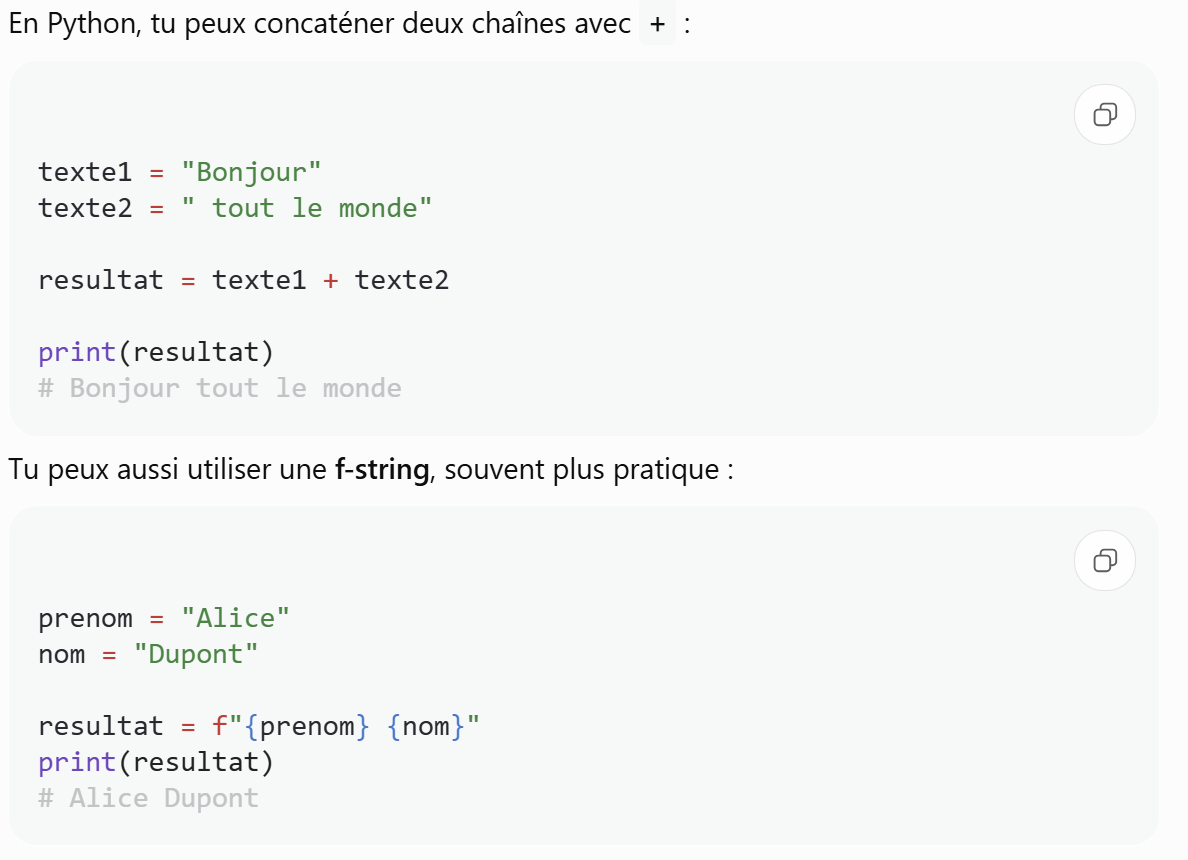

In [4]:
# cast to float first, then compare as numbers
print("is", reading_day1, "warmer than", reading_day3, "?", float(reading_day1) > float(reading_day3))


is -8.4 warmer than -9.2 ? True


<details>
<summary><b>🔍 Going deeper: floating-point precision (intéressant)</b></summary>

Floats are binary approximations of real numbers, so familiar decimals are not stored exactly:

```python
print(0.1 + 0.2)                       # 0.30000000000000004
print(0.1 + 0.2 == 0.3)                # False
import math
print(math.isclose(0.1 + 0.2, 0.3))    # True
```

Never test floats for equality with `==`; use `math.isclose` (or `numpy.isclose` for arrays) with an explicit tolerance. This matters whenever you compare or threshold measured quantities.

</details>

**📌 Takeaways**

- Every value has a **type** — `int`, `float`, `str`, `bool`, or `None` — and `type()` reveals it. The type decides what an operator does: `+` adds numbers but joins strings.
- Data read from a text file is always **text**; cast it with `float()` or `int()` before doing arithmetic or comparisons.
- Comparing strings works character by character, so `'-8.4' > '-9.2'` is `False` even though -8.4 °C is the warmer day — a silent bug when text should be numbers.
- Name variables for the **quantity and its unit** (`temp_celsius`), and format them clearly with **f-strings** (`f"{temp_celsius:.1f} °C"`).
- Bring in extra tools with `import` (for example `import math`) — the standard library is full of ready-made toolboxes.
- *(Going deeper)* Floats are approximate, so never test them with `==`; use `math.isclose` instead.

## Summary

| Concept | Rule to remember |
|---|---|
| Types | Every value has a type; `type()` shows it (`int`, `float`, `str`, `bool`, `None`). |
| Casting | Text from a file is `str`; use `float()` or `int()` before doing maths. |
| Operators | `+` adds numbers but joins strings; `/` always gives a `float`. |
| Comparison | Strings compare character by character, not by numeric value. |
| Naming | Encode the quantity and unit: `temp_celsius`, `pressure_pa`. |
| Formatting | `f"{value:.2f}"` fixes the number of decimals shown. |
| Files      | Use `pathlib.Path` with a `with path.open(mode)` block; `"w"` overwrites, `"a"` appends. |

## Resources

- [Project Pythia Foundations](https://foundations.projectpythia.org/) — geoscience-flavoured tutorials on the core scientific-Python stack; the natural next step after this chapter.
- [The Python tutorial](https://docs.python.org/3/tutorial/) — the authoritative reference for the built-in types and syntax used above.